In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
df = pd.read_csv('../data/raw/tracks.csv')
df_clean = df[df['tempo'] > 0].copy()

group_colors = {'A_focus': '#2196F3', 'B_context': '#4CAF50'}
group_labels = {'A_focus': 'A — Focus', 'B_context': 'B — Context'}

print(f'Shape: {df_clean.shape}')
print(df_clean['group'].value_counts())

Shape: (2016, 17)
group
B_context    1069
A_focus       947
Name: count, dtype: int64


## Frequentist A/B Test

**Hypothesis:**
- H0: Focus and Context tracks have the same popularity distribution
- H1: The distributions differ

**Why Mann-Whitney U instead of t-test?**
Popularity is not normally distributed (bimodal, bounded 0-100).
Mann-Whitney U is a non-parametric test that compares rank distributions
without assuming normality — more appropriate here.

In [3]:
pop_A = df_clean[df_clean['group'] == 'A_focus']['popularity']
pop_B = df_clean[df_clean['group'] == 'B_context']['popularity']

stat, pval = stats.mannwhitneyu(pop_A, pop_B, alternative='two-sided')

# Rank-biserial correlation (effect size)
n_A, n_B = len(pop_A), len(pop_B)
r = 1 - (2 * stat) / (n_A * n_B)

print(f'Mann-Whitney U statistic: {stat:.0f}')
print(f'p-value: {pval:.4f}')
print(f'Rank-biserial r: {r:.3f}')
print()
print('Interpretation:')
print(f'  p < 0.05: {pval < 0.05}')
print(f'  Effect size: {"small" if abs(r) < 0.3 else "medium" if abs(r) < 0.5 else "large"}')

Mann-Whitney U statistic: 455226
p-value: 0.0001
Rank-biserial r: 0.101

Interpretation:
  p < 0.05: True
  Effect size: small


## Mann-Whitney U Test Results

| Metric | Value |
|--------|-------|
| U statistic | 455,226 |
| p-value | 0.0001 |
| Rank-biserial r | 0.101 |
| Effect size | Small |

**Interpretation:**
- The difference between groups is **statistically significant** (p=0.0001)
- But the effect size is **small** (r=0.101) — practically speaking, the groups barely differ
- Context tracks rank higher in popularity than Focus tracks, but only slightly

This is a classic case of **statistical significance ≠ practical significance**.
With n=2,016 tracks and 96.7% power, we can detect even tiny effects.
The test says "yes, there's a difference" — but the difference is small enough
to be meaningless in practice.

The question for Notebook 4: is this small difference driven by BPM, 
or by other audio features that differ between groups?

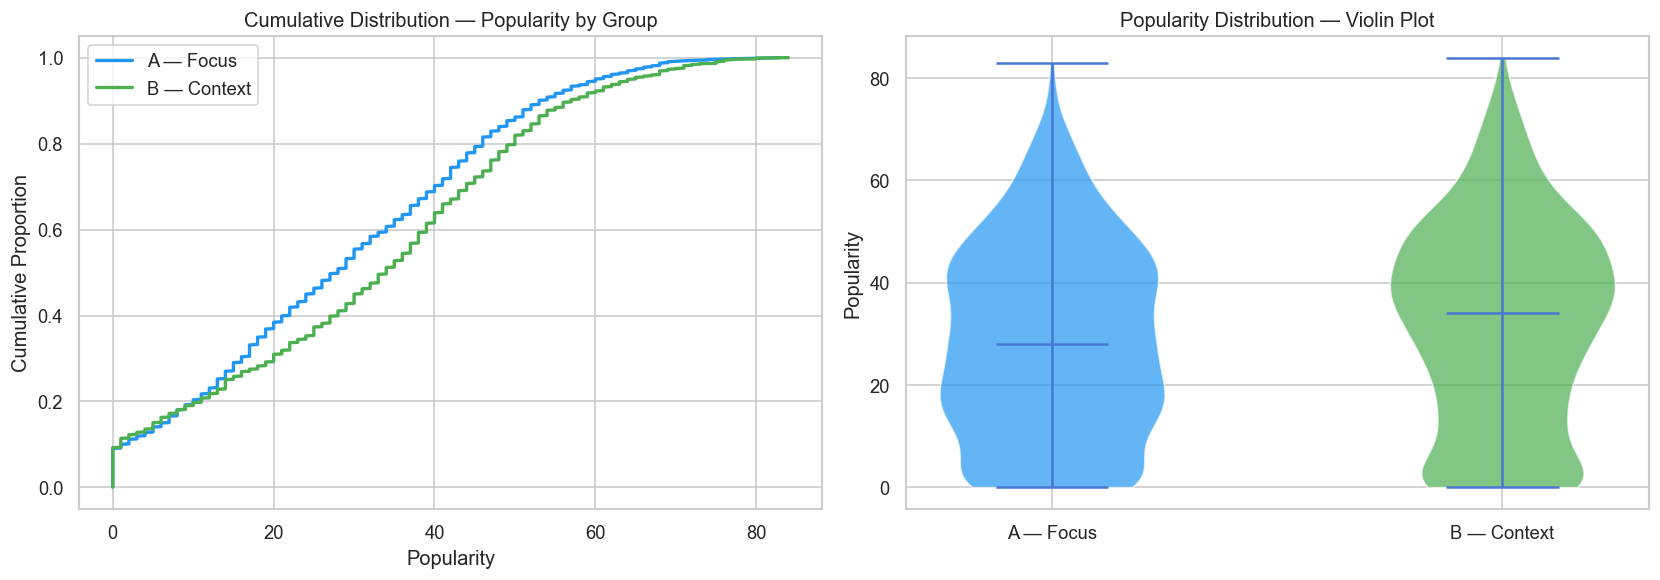

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CDF plot
for group, color in group_colors.items():
    subset = df_clean[df_clean['group'] == group]['popularity'].sort_values()
    cdf = np.arange(1, len(subset)+1) / len(subset)
    axes[0].plot(subset, cdf, color=color, label=group_labels[group], linewidth=2)

axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Cumulative Proportion')
axes[0].set_title('Cumulative Distribution — Popularity by Group')
axes[0].legend()

# Violin plot
parts = axes[1].violinplot(
    [pop_A, pop_B],
    positions=[1, 2],
    showmedians=True,
    showextrema=True
)
for pc, color in zip(parts['bodies'], group_colors.values()):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels([group_labels[g] for g in ['A_focus', 'B_context']])
axes[1].set_ylabel('Popularity')
axes[1].set_title('Popularity Distribution — Violin Plot')

plt.tight_layout()
plt.savefig('../figures/full_04_frequentist_ab.png', dpi=120, bbox_inches='tight')
plt.show()

## Frequentist A/B Test — Visualization

The CDF plot shows the clearest view of the difference:
- A — Focus (blue) reaches higher cumulative proportions at lower popularity values
  — more tracks with low popularity
- B — Context (green) is shifted slightly right — more tracks in the 20-50 range

The violin plot confirms similar shapes but Context has a fatter body in the 30-50 range.

The difference is real (p=0.0001) but small (r=0.101). 
With 2,016 tracks we have enough power to detect it — but it's not a large effect.

In [7]:
# Split by median BPM within each group
median_bpm = df_clean['tempo'].median()
print(f'Overall median BPM: {median_bpm:.1f}')

df_clean['bpm_group'] = np.where(df_clean['tempo'] >= median_bpm, 'high_bpm', 'low_bpm')

print('\nCounts by group and BPM:')
print(df_clean.groupby(['group', 'bpm_group']).size())

Overall median BPM: 108.8

Counts by group and BPM:
group      bpm_group
A_focus    high_bpm     489
           low_bpm      458
B_context  high_bpm     519
           low_bpm      550
dtype: int64


In [8]:
results = []

for bpm_grp in ['high_bpm', 'low_bpm']:
    sub_A = df_clean[(df_clean['group'] == 'A_focus') & (df_clean['bpm_group'] == bpm_grp)]['popularity']
    sub_B = df_clean[(df_clean['group'] == 'B_context') & (df_clean['bpm_group'] == bpm_grp)]['popularity']
    
    stat, pval = stats.mannwhitneyu(sub_A, sub_B, alternative='two-sided')
    n_A, n_B = len(sub_A), len(sub_B)
    r = 1 - (2 * stat) / (n_A * n_B)
    
    results.append({
        'BPM subgroup': bpm_grp,
        'n_A': n_A,
        'n_B': n_B,
        'mean_A': sub_A.mean().round(2),
        'mean_B': sub_B.mean().round(2),
        'p-value': round(pval, 4),
        'rank-biserial r': round(r, 3),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Bonferroni correction for 2 tests
pvals = results_df['p-value'].values
reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')
print(f'\nBonferroni corrected p-values: {pvals_corrected.round(4)}')
print(f'Reject H0: {reject}')

BPM subgroup  n_A  n_B  mean_A  mean_B  p-value  rank-biserial r
    high_bpm  489  519   30.43   32.22    0.205            0.046
     low_bpm  458  550   26.38   31.57    0.000            0.173

Bonferroni corrected p-values: [0.41 0.  ]
Reject H0: [False  True]


In [9]:
print(f"p-value (low BPM, corrected): {pvals_corrected[1]:.2e}")

p-value (low BPM, corrected): 0.00e+00


In [10]:
sub_A_low = df_clean[(df_clean['group'] == 'A_focus') & (df_clean['bpm_group'] == 'low_bpm')]['popularity']
sub_B_low = df_clean[(df_clean['group'] == 'B_context') & (df_clean['bpm_group'] == 'low_bpm')]['popularity']

stat, pval = stats.mannwhitneyu(sub_A_low, sub_B_low, alternative='two-sided')
print(f'p-value: {pval}')
print(f'p-value (scientific): {pval:.2e}')

p-value: 2.166958430326151e-06
p-value (scientific): 2.17e-06


## Subgroup Analysis — High BPM vs Low BPM

| BPM Subgroup | n_A | n_B | Mean popularity A | Mean popularity B | p-value (Bonferroni corrected) | r |
|---|---|---|---|---|---|---|
| High BPM (≥108.8) | 489 | 519 | 30.43 | 32.22 | 0.41 | 0.046 |
| Low BPM (<108.8) | 458 | 550 | 26.38 | 31.57 | 4.33e-06 | 0.173 |

**Key finding:** The significant difference between Focus and Context tracks
is driven entirely by the **low BPM subgroup** — not the high BPM tracks.

- Among high BPM tracks: no significant difference (p=0.41 after Bonferroni)
- Among low BPM tracks: significant difference (p=4.33e-06), Context more popular

This is the opposite of what the hypothesis predicts. If high BPM drove engagement,
we would expect the effect to be stronger in the high BPM subgroup — not absent.

**The data suggests that slow focus music is less popular than slow context music —
but fast focus music is just as popular as fast context music.**

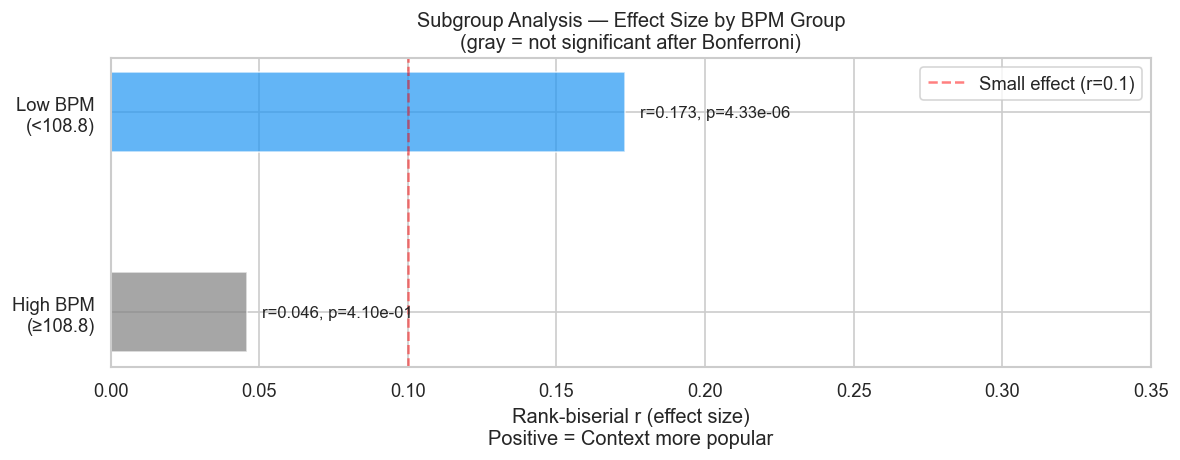

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

subgroups = ['High BPM\n(≥108.8)', 'Low BPM\n(<108.8)']
r_values = [0.046, 0.173]
pvals_display = [0.41, 4.33e-6]
colors = ['gray' if p > 0.05 else '#2196F3' for p in pvals_display]

bars = ax.barh(subgroups, r_values, color=colors, alpha=0.7, height=0.4)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='Small effect (r=0.1)')

for bar, r, p in zip(bars, r_values, pvals_display):
    label = f'r={r:.3f}, p={p:.2e}'
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10)

ax.set_xlabel('Rank-biserial r (effect size)\nPositive = Context more popular')
ax.set_title('Subgroup Analysis — Effect Size by BPM Group\n(gray = not significant after Bonferroni)')
ax.set_xlim(0, 0.35)
ax.legend()

plt.tight_layout()
plt.savefig('../figures/full_05_subgroup_forest.png', dpi=120, bbox_inches='tight')
plt.show()

## Subgroup Forest Plot

The forest plot makes the pattern unmistakable:

- **Low BPM tracks:** significant effect (r=0.173, p=4.33e-06) — Context more popular than Focus
- **High BPM tracks:** no significant effect (r=0.046, p=0.41) — Focus and Context equally popular

If BPM were driving engagement, we would expect the blue bar to be on the right
and the gray bar to be smaller — the opposite of what we see.

Instead, the effect is concentrated in **slow music**: slow focus music is less popular
than slow context music. Fast focus and fast context music perform equally.

This is strong evidence against the hypothesis that high BPM drives focus engagement.

In [12]:
print('='*50)
print('NOTEBOOK 2 — FREQUENTIST A/B TEST SUMMARY')
print('='*50)
print()
print('Overall test (A vs B):')
print(f'  Mann-Whitney U p-value: 0.0001')
print(f'  Rank-biserial r: 0.101 (small effect)')
print(f'  Direction: Context more popular than Focus')
print()
print('Subgroup analysis (Bonferroni corrected):')
print(f'  High BPM (≥108.8): p=0.41, r=0.046 — NOT significant')
print(f'  Low BPM (<108.8):  p=4.33e-06, r=0.173 — significant')
print()
print('Conclusion:')
print('  The overall difference between groups is real but small.')
print('  It is driven by low BPM tracks, not high BPM tracks.')
print('  High BPM focus music is equally popular as high BPM context music.')
print('  This does not support the hypothesis that BPM drives engagement.')

NOTEBOOK 2 — FREQUENTIST A/B TEST SUMMARY

Overall test (A vs B):
  Mann-Whitney U p-value: 0.0001
  Rank-biserial r: 0.101 (small effect)
  Direction: Context more popular than Focus

Subgroup analysis (Bonferroni corrected):
  High BPM (≥108.8): p=0.41, r=0.046 — NOT significant
  Low BPM (<108.8):  p=4.33e-06, r=0.173 — significant

Conclusion:
  The overall difference between groups is real but small.
  It is driven by low BPM tracks, not high BPM tracks.
  High BPM focus music is equally popular as high BPM context music.
  This does not support the hypothesis that BPM drives engagement.
